# Étape 1 : Exploration des Données (EDA) - PySpark

## Objectif
Comprendre la structure et la qualité des données disponibles pour construire notre modèle prédictif **en utilisant PySpark**.

## Datasets à explorer
1. **counting_data_april_2022.csv** : Données de comptage vélo
2. **temperature_converted.csv** : Données de température
3. **eau_converted.csv** : Données de pluviométrie

---

## 1.1 Initialisation de Spark et Import des bibliothèques

**Différence clé avec Pandas :**
- Pandas : `import pandas as pd` → travaille en mémoire sur une seule machine
- PySpark : `SparkSession` → peut distribuer le calcul sur plusieurs machines

**Pourquoi PySpark ?**
- Scalable : fonctionne sur de très gros volumes de données
- Parallélisation : calculs répartis automatiquement
- Lazy evaluation : les transformations ne s'exécutent que quand nécessaire

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, isnan, when, desc
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns

# Créer une Spark Session
# master("local[*]") = utilise tous les coeurs CPU disponibles en local
spark = SparkSession.builder \
    .appName("MeteoVelo - Exploration") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark Session créée!")
print(f"Version de Spark : {spark.version}")
print(f"Spark UI : http://localhost:4040")

Spark Session créée!
Version de Spark : 3.5.3
Spark UI : http://localhost:4040


---
## 1.2 Chargement des Données Vélo

**PySpark vs Pandas :**
```python
# Pandas
df = pd.read_csv('file.csv', sep=';')

# PySpark
df = spark.read.csv('file.csv', header=True, inferSchema=True, sep=';')
```

**Options importantes :**
- `header=True` : La 1ère ligne contient les noms de colonnes
- `inferSchema=True` : Spark devine automatiquement les types (int, string, etc.)
- `sep=';'` : Séparateur des colonnes

In [2]:
# Chargement du fichier CSV
df_velo = spark.read.csv('../CSVs/counting_data_april_2022.csv', 
                          header=True, 
                          inferSchema=True, 
                          sep=';')

print("Dataset vélo chargé!")
print(f"📊 Dimensions : {df_velo.count():,} lignes x {len(df_velo.columns)} colonnes")
print("\n" + "="*80)
print("Aperçu des 5 premières lignes :")
df_velo.show(5, truncate=False)

Dataset vélo chargé!
📊 Dimensions : 262,872 lignes x 5 colonnes

Aperçu des 5 premières lignes :
+----------+-----+-----------+-------------------+-------------------+
|channel_id|count|counter_id |end_datetime       |start_datetime     |
+----------+-----+-----------+-------------------+-------------------+
|102017788 |0    |X2H14116817|2022-04-07 02:00:00|2022-04-07 01:00:00|
|102017788 |0    |X2H14116817|2022-04-07 01:00:00|2022-04-07 00:00:00|
|102017788 |0    |X2H14116817|2022-04-07 00:00:00|2022-04-06 23:00:00|
|102017788 |0    |X2H14116817|2022-04-06 23:00:00|2022-04-06 22:00:00|
|102017788 |0    |X2H14116817|2022-04-06 22:00:00|2022-04-06 21:00:00|
+----------+-----+-----------+-------------------+-------------------+
only showing top 5 rows



In [3]:
# Schema du DataFrame (équivalent de df.info() en Pandas)
print("📋 Schema du DataFrame :")
print("="*80)
df_velo.printSchema()

📋 Schema du DataFrame :
root
 |-- channel_id: integer (nullable = true)
 |-- count: integer (nullable = true)
 |-- counter_id: string (nullable = true)
 |-- end_datetime: timestamp (nullable = true)
 |-- start_datetime: timestamp (nullable = true)



In [4]:
# Liste des colonnes
print("🔍 Colonnes disponibles dans le dataset vélo :")
print("="*80)
for i, col_name in enumerate(df_velo.columns, 1):
    print(f"{i}. {col_name}")

🔍 Colonnes disponibles dans le dataset vélo :
1. channel_id
2. count
3. counter_id
4. end_datetime
5. start_datetime


**💡 Colonnes identifiées :**
- `count` → **Nombre de vélos** (notre variable cible !)
- `start_datetime` / `end_datetime` → Timestamp des comptages
- `channel_id` → Identifiant du site de comptage

In [5]:
# Statistiques descriptives (équivalent de df.describe())
print("Statistiques descriptives :")
print("="*80)
df_velo.describe().show()

Statistiques descriptives :
+-------+--------------------+------------------+-----------+
|summary|          channel_id|             count| counter_id|
+-------+--------------------+------------------+-----------+
|  count|              262872|            262872|     164736|
|   mean| 1.782978983376244E8|26.669477920813172|       NULL|
| stddev|1.1564130274301077E8| 52.82175829948992|       NULL|
|    min|           100029815|                 0|CAIE13EA6F3|
|    max|           353309133|              1008|X2H21070267|
+-------+--------------------+------------------+-----------+



---
## 1.3 Chargement des Données Température

In [6]:
# Chargement des données de température
df_temp = spark.read.csv('../CSVs/temperature_converted.csv', 
                          header=True, 
                          inferSchema=True, 
                          sep=';')

print("Dataset température chargé!")
print(f"Dimensions : {df_temp.count():,} lignes x {len(df_temp.columns)} colonnes")
print("\n" + "="*80)
print("Aperçu des 5 premières lignes :")
df_temp.show(5, truncate=False)

Dataset température chargé!
Dimensions : 26,618 lignes x 3 colonnes

Aperçu des 5 premières lignes :
+----------------+-------------------+-------------+
|deveui          |horodate           |degre_celsius|
+----------------+-------------------+-------------+
|70b3d580a0100605|2022-04-29 23:59:00|14,75        |
|70b3d580a0100647|2022-04-29 23:58:00|14           |
|70b3d580a0100648|2022-04-29 23:56:00|13,625       |
|70b3d580a0100623|2022-04-29 23:52:00|13,5625      |
|70b3d580a0100654|2022-04-29 23:51:00|15,25        |
+----------------+-------------------+-------------+
only showing top 5 rows



In [7]:
# Schema
print("Schema température :")
print("="*80)
df_temp.printSchema()

Schema température :
root
 |-- deveui: string (nullable = true)
 |-- horodate: timestamp (nullable = true)
 |-- degre_celsius: string (nullable = true)



In [8]:
# Statistiques
print("Statistiques température :")
print("="*80)
df_temp.describe().show()

Statistiques température :
+-------+----------------+------------------+
|summary|          deveui|     degre_celsius|
+-------+----------------+------------------+
|  count|           26618|             26618|
|   mean|            NULL|12.444444444444445|
| stddev|            NULL| 5.596072363282877|
|    min|70b3d580a0100543|            -0,125|
|    max|70b3d580a01007a5|            9,9375|
+-------+----------------+------------------+



**🚨 ATTENTION :** La colonne `degre_celsius` est de type **STRING** au lieu de numérique !

→ Il faudra la convertir en float dans l'étape 2

---
## 1.4 Chargement des Données Pluviométrie

In [9]:
# Chargement des données de pluviométrie
df_pluie = spark.read.csv('../CSVs/eau_converted.csv', 
                           header=True, 
                           inferSchema=True, 
                           sep=';')

print("Dataset pluviométrie chargé!")
print(f"Dimensions : {df_pluie.count():,} lignes x {len(df_pluie.columns)} colonnes")
print("\n" + "="*80)
print("Aperçu des 5 premières lignes :")
df_pluie.show(5, truncate=False)

Dataset pluviométrie chargé!
Dimensions : 5,866 lignes x 3 colonnes

Aperçu des 5 premières lignes :
+-----------+-------------------+--------+
|identifiant|horodate           |pluie_mm|
+-----------+-------------------+--------+
|1          |2022-04-29 19:42:00|0,1     |
|1          |2022-04-29 19:36:00|0,1     |
|1          |2022-04-26 00:24:00|0,1     |
|1          |2022-04-26 00:12:00|0,1     |
|1          |2022-04-26 00:06:00|0,1     |
+-----------+-------------------+--------+
only showing top 5 rows



In [10]:
# Schema
print("Schema pluviométrie :")
print("="*80)
df_pluie.printSchema()

Schema pluviométrie :
root
 |-- identifiant: integer (nullable = true)
 |-- horodate: timestamp (nullable = true)
 |-- pluie_mm: string (nullable = true)



In [11]:
# Statistiques
print("Statistiques pluviométrie :")
print("="*80)
df_pluie.describe().show()

Statistiques pluviométrie :
+-------+------------------+------------------+
|summary|       identifiant|          pluie_mm|
+-------+------------------+------------------+
|  count|              5866|              5866|
|   mean|16.998295260825095|               1.2|
| stddev| 10.11111315331209|0.6324555320336759|
|    min|                 1|               0,1|
|    max|                37|               3,2|
+-------+------------------+------------------+



**ATTENTION :** La colonne `pluie_mm` est aussi de type **STRING** !

→ Conversion nécessaire en étape 2

---
## 1.5 Analyse de la Qualité des Données

### 1.5.1 Valeurs Manquantes (NaN)

In [12]:
# Fonction pour analyser les valeurs manquantes en PySpark
def analyse_valeurs_manquantes_spark(df, nom_dataset):
    print(f"\n{'='*80}")
    print(f"Valeurs manquantes - {nom_dataset}")
    print(f"{'='*80}")
    
    # Compter les NaN/NULL pour chaque colonne
    # En PySpark, on utilise count(when(col.isNull())) pour chaque colonne
    total_rows = df.count()
    
    missing_data = []
    for col_name in df.columns:
        null_count = df.filter(col(col_name).isNull()).count()
        if null_count > 0:
            missing_data.append({
                'Colonne': col_name,
                'Nb_Manquantes': null_count,
                'Pourcentage': (null_count / total_rows) * 100
            })
    
    if len(missing_data) == 0:
        print("Aucune valeur manquante détectée!")
    else:
        for row in sorted(missing_data, key=lambda x: x['Nb_Manquantes'], reverse=True):
            print(f"{row['Colonne']:<20} {row['Nb_Manquantes']:>10,} ({row['Pourcentage']:>6.2f}%)")

# Analyser chaque dataset
analyse_valeurs_manquantes_spark(df_velo, "Données Vélo")
analyse_valeurs_manquantes_spark(df_temp, "Données Température")
analyse_valeurs_manquantes_spark(df_pluie, "Données Pluviométrie")


Valeurs manquantes - Données Vélo
counter_id               98,136 ( 37.33%)

Valeurs manquantes - Données Température
Aucune valeur manquante détectée!

Valeurs manquantes - Données Pluviométrie
Aucune valeur manquante détectée!


### 1.5.2 Vérification des Formats de Dates

In [13]:
# Identifier les colonnes de type date/time
print("Recherche des colonnes de type date/time...\n")

print("Dataset VÉLO :")
date_cols_velo = [col_name for col_name in df_velo.columns if 'date' in col_name.lower() or 'time' in col_name.lower()]
print(f"Colonnes potentielles : {date_cols_velo}")

print("\nDataset TEMPÉRATURE :")
date_cols_temp = [col_name for col_name in df_temp.columns if 'date' in col_name.lower() or 'time' in col_name.lower()]
print(f"Colonnes potentielles : {date_cols_temp}")

print("\nDataset PLUIE :")
date_cols_pluie = [col_name for col_name in df_pluie.columns if 'date' in col_name.lower() or 'time' in col_name.lower()]
print(f"Colonnes potentielles : {date_cols_pluie}")

Recherche des colonnes de type date/time...

Dataset VÉLO :
Colonnes potentielles : ['end_datetime', 'start_datetime']

Dataset TEMPÉRATURE :
Colonnes potentielles : ['horodate']

Dataset PLUIE :
Colonnes potentielles : ['horodate']


---
## 1.6 Visualisations Exploratoires

**Note :** Pour visualiser des données Spark, on doit les convertir en Pandas avec `.toPandas()`

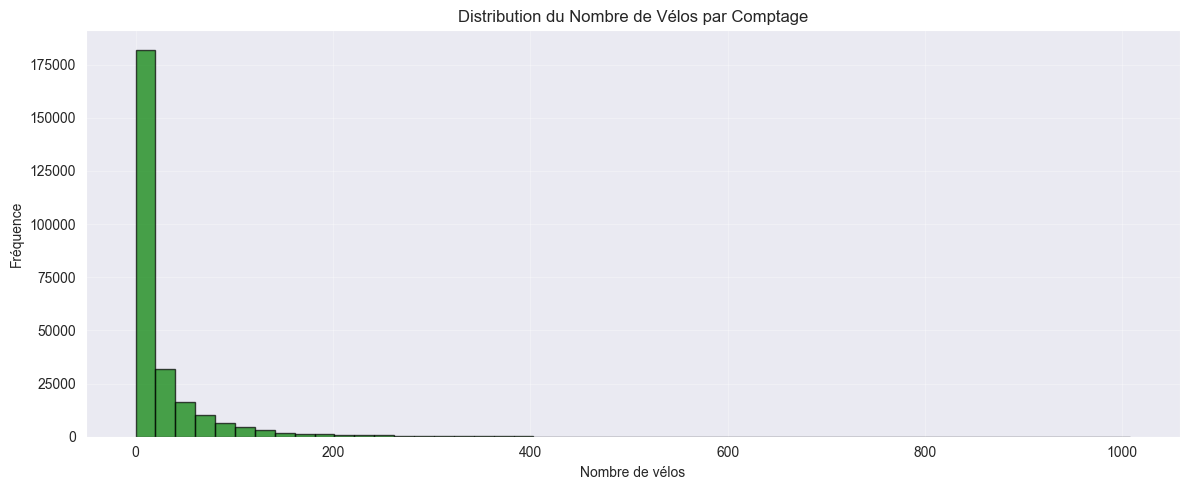

La plupart des comptages sont proches de 0 (heures creuses ou sites peu fréquentés)


In [14]:
# Distribution du nombre de vélos
# En Spark, on collecte un échantillon pour visualiser
velo_sample = df_velo.select('count').toPandas()

plt.figure(figsize=(12, 5))
plt.hist(velo_sample['count'], bins=50, edgecolor='black', color='green', alpha=0.7)
plt.xlabel('Nombre de vélos')
plt.ylabel('Fréquence')
plt.title('Distribution du Nombre de Vélos par Comptage')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"La plupart des comptages sont proches de 0 (heures creuses ou sites peu fréquentés)")

---
## 1.7 Résumé de l'Exploration

### Findings

**1. Données Vélo :**
- Nombre de lignes : 262,872
- Colonne de comptage : `count`
- Colonnes temporelles : `start_datetime`, `end_datetime`
- Valeurs manquantes : `counter_id` (37%)
- **Type des dates :** STRING (à convertir en timestamp)

**2. Données Température :**
- Nombre de lignes : ~26,618
- Colonne température : `degre_celsius`
- Colonne temporelle : `horodate`
- **Type :** STRING avec virgule (ex: "14,75") → à convertir en FLOAT
- 17 capteurs différents

**3. Données Pluviométrie :**
- Nombre de lignes : ~5,866
- Colonne précipitation : `pluie_mm`
- Colonne temporelle : `horodate`
- **Type :** STRING avec virgule → à convertir en FLOAT
- **IMPORTANT :** Ne contient QUE les heures où il a plu (16 jours sur 30)

### Prochaines Étapes (Notebook 02)

1. Convertir les colonnes temporelles en `timestamp`
2. Convertir température et pluie : STRING → FLOAT (remplacer `,` par `.`)
3. Agréger les données météo par heure (moyenne des capteurs)
4. Agréger les données vélo par heure (somme de tous les sites)
5. Fusionner les 3 datasets avec LEFT JOIN
6. Remplir les NaN de pluie par 0 (pas de pluie)
7. Sauvegarder le dataset fusionné

---
**Étape 1 terminée !**

In [15]:
# Arrêter la Spark Session (IMPORTANT!)
spark.stop()
print("Spark Session arrêtée!")

Spark Session arrêtée!
